# IT549: Deep Learning
## Lab Assignment 4 — Object Detection Evolution: From R-CNN to YOLO
**Name:** Het Monpara &nbsp;&nbsp; **ID:** 202511016

---

In [1]:
import os, time, random, glob, shutil
import xml.etree.ElementTree as ET

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import yaml

import torch
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import torchvision.ops as ops
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch  : {torch.__version__}")
print(f"NumPy    : {np.__version__}")
print(f"OpenCV   : {cv2.__version__}")
print(f"Device   : {device}")

PyTorch  : 2.2.2+cpu
NumPy    : 1.26.4
OpenCV   : 4.13.0
Device   : cpu


In [2]:


TRAIN_DIR = './archive/train_zip/train'
TEST_DIR  = './archive/test_zip/test'

CLASS_NAMES  = {0: 'apple', 1: 'banana', 2: 'orange'}
NAME_TO_ID   = {'apple': 0, 'banana': 1, 'orange': 2}
CLASS_COLORS = {'apple': (220,50,50), 'banana': (240,200,0), 'orange': (255,140,0)}

train_images = sorted(glob.glob(TRAIN_DIR + '/*.jpg'))
test_images  = sorted(glob.glob(TEST_DIR  + '/*.jpg'))

print(f"Train images : {len(train_images)}")
print(f"Test images  : {len(test_images)}")

Train images : 240
Test images  : 60


---
## Preparation — Ground Truth Visualization

In [3]:
# Cell 4 — Parse XML label
def parse_xml(xml_path):
    boxes = []
    if not os.path.exists(xml_path):
        return boxes
    tree = ET.parse(xml_path)
    root = tree.getroot()
    for obj in root.findall('object'):
        name = obj.find('name').text.lower()
        if name not in NAME_TO_ID:
            continue
        bb = obj.find('bndbox')
        x1 = int(float(bb.find('xmin').text))
        y1 = int(float(bb.find('ymin').text))
        x2 = int(float(bb.find('xmax').text))
        y2 = int(float(bb.find('ymax').text))
        boxes.append((NAME_TO_ID[name], x1, y1, x2, y2))
    return boxes

print("parse_xml() ready.")

parse_xml() ready.


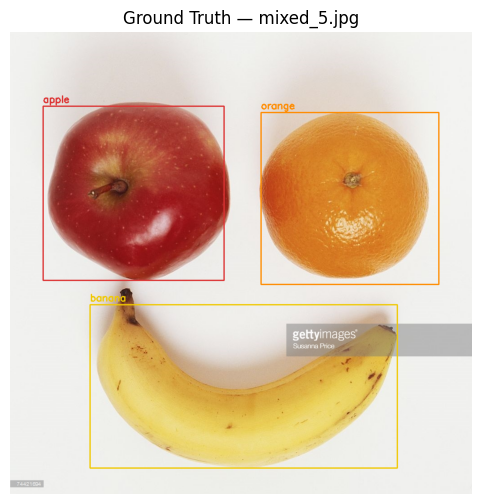

Boxes found: 3


In [4]:
# Cell 5 — Load image + draw ground truth boxes
random.seed(42)
img_path = random.choice(train_images)
xml_path = img_path.replace('.jpg', '.xml')

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gt_boxes = parse_xml(xml_path)

vis = img_rgb.copy()
for (cls_id, x1, y1, x2, y2) in gt_boxes:
    name  = CLASS_NAMES[cls_id]
    color = CLASS_COLORS[name]
    cv2.rectangle(vis, (x1,y1), (x2,y2), color, 2)
    cv2.putText(vis, name, (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

plt.figure(figsize=(8,6))
plt.imshow(vis)
plt.title(f"Ground Truth — {os.path.basename(img_path)}")
plt.axis('off')
plt.show()
print(f"Boxes found: {len(gt_boxes)}")

In [5]:
# Cell 6 — IoU function
def compute_iou(boxA, boxB):
    # Intersection
    x1 = max(boxA[0], boxB[0])
    y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2])
    y2 = min(boxA[3], boxB[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    # Union
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return 0.0 if union == 0 else inter / union

print("compute_iou() defined.")

compute_iou() defined.


In [6]:
# Cell 7 — IoU demo (3 cases)
cases = [
    ('Highly overlapping',  [10,10,100,100], [15,15, 95, 95]),
    ('Partially overlapping',[10,10, 80, 80], [50,50,120,120]),
    ('Completely disjoint',  [10,10, 50, 50], [60,60,100,100]),
]

print(f"{'Case':<25} {'IoU':>6}")
print('-'*33)
for desc, a, b in cases:
    print(f"{desc:<25} {compute_iou(a,b):>6.4f}")

Case                         IoU
---------------------------------
Highly overlapping        0.7901
Partially overlapping     0.1011
Completely disjoint       0.0000


---
## Task 2 — Selective Search (R-CNN Step 1)

In [7]:
# Cell 8 — Run Selective Search
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img_bgr)
ss.switchToSelectiveSearchFast()

t0 = time.time()
proposals = ss.process()   # (x, y, w, h)
print(f"Total proposals : {len(proposals)}")
print(f"Time taken      : {time.time()-t0:.2f} s")

proposals_200 = proposals[:200]
top_100       = proposals[:100]

Total proposals : 1815
Time taken      : 6.59 s


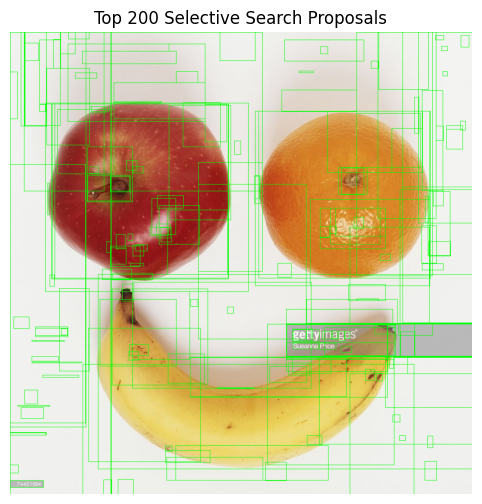

In [8]:
# Cell 9 — Visualize 200 proposals
vis2 = img_rgb.copy()
for (x,y,w,h) in proposals_200:
    cv2.rectangle(vis2, (x,y), (x+w,y+h), (0,255,0), 1)

plt.figure(figsize=(8,6))
plt.imshow(vis2)
plt.title('Top 200 Selective Search Proposals')
plt.axis('off')
plt.show()

---
## Task 3 — R-CNN Bottleneck (100 crops → CNN)

In [9]:
# Cell 10 — Load ResNet18, remove final layers
resnet18_full = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Feature extractor = all layers except avgpool and fc
feature_extractor = torch.nn.Sequential(
    resnet18_full.conv1,
    resnet18_full.bn1,
    resnet18_full.relu,
    resnet18_full.maxpool,
    resnet18_full.layer1,
    resnet18_full.layer2,
    resnet18_full.layer3,
    resnet18_full.layer4,
).eval().to(device)

print("ResNet18 feature extractor ready.")

ResNet18 feature extractor ready.


In [10]:
# Cell 11 — R-CNN loop: crop each proposal → resize → pass through CNN
# Uses PIL to avoid the NumPy/ToTensor conflict
H, W = img_rgb.shape[:2]

crop_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

rcnn_start = time.time()
feature_vectors = []

with torch.no_grad():
    for (x, y, w, h) in top_100:
        x1, y1 = max(0,x),   max(0,y)
        x2, y2 = min(W,x+w), min(H,y+h)
        if x2<=x1 or y2<=y1:
            continue
        # Crop as PIL image (avoids numpy ToTensor bug)
        crop_pil = Image.fromarray(img_rgb[y1:y2, x1:x2])
        tensor   = crop_transform(crop_pil).unsqueeze(0).to(device)
        feat     = feature_extractor(tensor)
        feature_vectors.append(feat.cpu())

rcnn_time = time.time() - rcnn_start

print(f"Crops processed       : {len(feature_vectors)}")
print(f"Total time (R-CNN)    : {rcnn_time:.4f} s  ({rcnn_time*1000:.2f} ms)")
print(f"Avg per crop          : {rcnn_time/len(feature_vectors)*1000:.2f} ms")

Crops processed       : 100
Total time (R-CNN)    : 3.2451 s  (3245.07 ms)
Avg per crop          : 32.45 ms


---
## Task 4 — Fast R-CNN (RoI Pooling)

In [11]:
# Cell 12 — Single forward pass on full image
full_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

img_pil    = Image.fromarray(img_rgb)
img_tensor = full_transform(img_pil).unsqueeze(0).to(device)   # (1,3,H,W)

fast_start = time.time()

with torch.no_grad():
    feature_map = feature_extractor(img_tensor)   # (1, 512, H/32, W/32)

print(f"Input tensor shape   : {img_tensor.shape}")
print(f"Feature map shape    : {feature_map.shape}")

Input tensor shape   : torch.Size([1, 3, 1024, 1024])
Feature map shape    : torch.Size([1, 512, 32, 32])


In [12]:
# Cell 13 — RoI Pooling on all 100 proposals
SPATIAL_SCALE = 1 / 32.0   # ResNet18 downsamples by 32x

# Build RoI tensor [batch_idx, x1, y1, x2, y2]
roi_list = []
for (x, y, w, h) in top_100:
    x1 = max(0.0, float(x))
    y1 = max(0.0, float(y))
    x2 = min(float(W), float(x+w))
    y2 = min(float(H), float(y+h))
    roi_list.append([0, x1, y1, x2, y2])

roi_tensor = torch.tensor(roi_list, dtype=torch.float32).to(device)

with torch.no_grad():
    pooled = ops.roi_pool(feature_map, roi_tensor,
                          output_size=7, spatial_scale=SPATIAL_SCALE)

fast_time = time.time() - fast_start

print(f"Pooled output shape  : {pooled.shape}")
print(f"Spatial scale        : {SPATIAL_SCALE} (stride=32)")
print()
print(f"R-CNN time           : {rcnn_time*1000:.2f} ms")
print(f"Fast R-CNN time      : {fast_time*1000:.2f} ms")
print(f"Speedup              : {rcnn_time/fast_time:.1f}x")

Pooled output shape  : torch.Size([100, 512, 7, 7])
Spatial scale        : 0.03125 (stride=32)

R-CNN time           : 3245.07 ms
Fast R-CNN time      : 340.02 ms
Speedup              : 9.5x


### Conceptual Analysis — Task 4

**Q: What redundant operations does Fast R-CNN eliminate?**

In R-CNN, every crop is passed through all convolutional layers **independently** — so overlapping regions are computed many times. Fast R-CNN runs the CNN **once** on the full image and uses RoI Pooling to extract features for all proposals from a single shared feature map. This removes N−1 redundant full forward passes.

---
## Task 5 — Faster R-CNN Inference

In [13]:
# Cell 14 — Load pre-trained Faster R-CNN
faster_rcnn = fasterrcnn_resnet50_fpn(
    weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
).eval().to(device)

print("Faster R-CNN (ResNet50+FPN) loaded.")

Faster R-CNN (ResNet50+FPN) loaded.


In [14]:
# Cell 15 — Run inference
COCO_CLASSES = [
    '__background__','person','bicycle','car','motorcycle','airplane','bus',
    'train','truck','boat','traffic light','fire hydrant','stop sign',
    'parking meter','bench','bird','cat','dog','horse','sheep','cow',
    'elephant','bear','zebra','giraffe','backpack','umbrella','handbag',
    'tie','suitcase','frisbee','skis','snowboard','sports ball','kite',
    'baseball bat','baseball glove','skateboard','surfboard','tennis racket',
    'bottle','wine glass','cup','fork','knife','spoon','bowl','banana',
    'apple','sandwich','orange','broccoli','carrot','hot dog','pizza',
    'donut','cake','chair','couch','potted plant','bed','dining table',
    'toilet','tv','laptop','mouse','remote','keyboard','cell phone',
    'microwave','oven','toaster','sink','refrigerator','book','clock',
    'vase','scissors','teddy bear','hair drier','toothbrush'
]

img_pil_t = Image.fromarray(img_rgb)
img_t     = T.ToTensor()(img_pil_t).to(device)

with torch.no_grad():
    preds = faster_rcnn([img_t])[0]

print(f"Total predictions : {len(preds['scores'])}")

Total predictions : 6


After filter >= 0.8 : 3 predictions


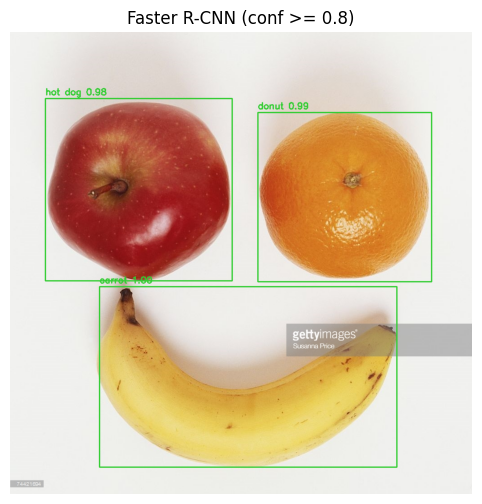

In [15]:
# Cell 16 — Filter conf >= 0.80 and visualize
CONF = 0.80
mask    = preds['scores'] >= CONF
f_boxes = preds['boxes'][mask]
f_lbls  = preds['labels'][mask]
f_scores= preds['scores'][mask]

print(f"After filter >= {CONF} : {len(f_boxes)} predictions")

vis3 = img_rgb.copy()
for box, lbl, score in zip(f_boxes, f_lbls, f_scores):
    x1,y1,x2,y2 = map(int, box.tolist())
    name = COCO_CLASSES[lbl.item()] if lbl.item() < len(COCO_CLASSES) else str(lbl.item())
    cv2.rectangle(vis3, (x1,y1), (x2,y2), (50,205,50), 2)
    cv2.putText(vis3, f"{name} {score:.2f}", (x1, max(y1-8,12)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (50,205,50), 2)

plt.figure(figsize=(8,6))
plt.imshow(vis3)
plt.title(f'Faster R-CNN (conf >= {CONF})')
plt.axis('off')
plt.show()

### Conceptual Analysis — Task 5

**Q: How does RPN eliminate Selective Search?**

Selective Search is a slow, hand-crafted CPU algorithm. The **RPN** is a small learned network that shares the backbone feature map already computed for detection. It evaluates anchor boxes at every spatial location and predicts objectness + box offsets. Because it reuses the same feature map and is trained end-to-end, it is faster and more accurate than Selective Search.

---
## Task 6 — Non-Maximum Suppression (NMS)

In [16]:
# Cell 17 — NMS function
def non_maximum_suppression(boxes, scores, iou_threshold=0.5):
    if not boxes:
        return [], []
    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    kept  = []
    while order:
        best  = order.pop(0)
        kept.append(best)
        order = [i for i in order
                 if compute_iou(boxes[best], boxes[i]) <= iou_threshold]
    return [boxes[i] for i in kept], [scores[i] for i in kept]

print("NMS function defined.")

NMS function defined.


In [17]:
# Cell 18 — NMS demo
demo_boxes  = [
    [ 50, 50,200,200],
    [ 55, 55,205,205],
    [ 60, 60,210,210],
    [250,250,400,400],
    [255,255,405,405],
]
demo_scores = [0.95, 0.88, 0.80, 0.91, 0.75]

kept_boxes, kept_scores = non_maximum_suppression(demo_boxes, demo_scores, iou_threshold=0.5)

print(f"Before NMS : {len(demo_boxes)} boxes")
print(f"After  NMS : {len(kept_boxes)} boxes")
for b, s in zip(kept_boxes, kept_scores):
    print(f"  {b}  score={s:.2f}")

Before NMS : 5 boxes
After  NMS : 2 boxes
  [50, 50, 200, 200]  score=0.95
  [250, 250, 400, 400]  score=0.91


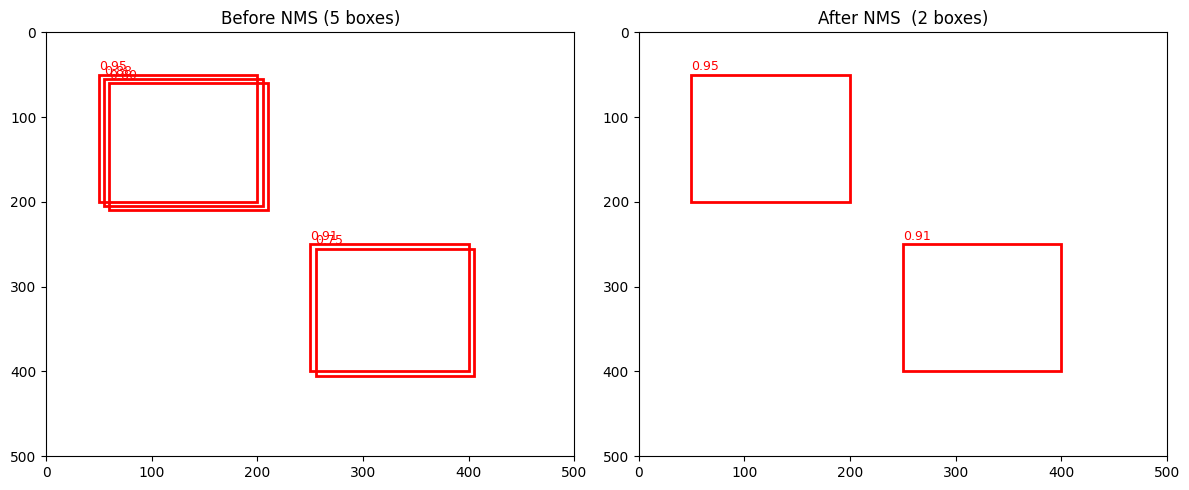

In [18]:
# Cell 19 — Visualize Before vs After NMS
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, title, boxes_to_show, scores_to_show in [
    (axes[0], f'Before NMS ({len(demo_boxes)} boxes)', demo_boxes, demo_scores),
    (axes[1], f'After NMS  ({len(kept_boxes)} boxes)', kept_boxes, kept_scores),
]:
    ax.set_xlim(0, 500); ax.set_ylim(500, 0)
    ax.set_title(title, fontsize=12)
    for b, s in zip(boxes_to_show, scores_to_show):
        rect = mpatches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1],
                                   linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(b[0], b[1]-5, f"{s:.2f}", color='red', fontsize=9)

plt.tight_layout()
plt.show()

### Conceptual Analysis — Task 6

**Q: IoU threshold 0.9 vs 0.1 for tightly packed apples?**

- **High (0.9):** Only nearly-identical boxes are suppressed. Adjacent apples survive → correct detections kept, but may have duplicate boxes for same apple.
- **Low (0.1):** Even slightly overlapping boxes are removed. Adjacent apples get suppressed → entire cluster collapses to 1 box, causing under-detection.

For tightly packed objects, use **0.5–0.7** to balance duplicates vs missed detections.

---
## Task 7 — YOLO Fine-Tuning

In [29]:
import sys, subprocess

def _install(pkg):
    """Try normal install, then --user fallback."""
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except subprocess.CalledProcessError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg,
                                '--quiet', '--user'],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

try:
    from ultralytics import YOLO
except ModuleNotFoundError:
    print('ultralytics not found – installing...')
    _install('ultralytics')
    from ultralytics import YOLO

print('YOLO imported successfully!')


YOLO imported successfully!


In [ ]:
YOLO_ROOT = os.path.join(os.getcwd(), "yolo_dataset")

def prepare_split(src_dir, split_name):
    img_out = os.path.join(YOLO_ROOT, split_name, 'images')
    lbl_out = os.path.join(YOLO_ROOT, split_name, 'labels')
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    imgs = sorted(glob.glob(src_dir + '/*.jpg'))
    ok, skip = 0, 0

    for img_path in imgs:
        xml_path = img_path.replace('.jpg', '.xml')
        if not os.path.exists(xml_path):
            skip += 1; continue

        img = cv2.imread(img_path)
        if img is None:
            skip += 1; continue
        ih, iw = img.shape[:2]

        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            lines = []
            for obj in root.findall('object'):
                name = obj.find('name').text.lower()
                if name not in NAME_TO_ID: continue
                bb   = obj.find('bndbox')
                xmin = float(bb.find('xmin').text)
                ymin = float(bb.find('ymin').text)
                xmax = float(bb.find('xmax').text)
                ymax = float(bb.find('ymax').text)
                xc = ((xmin+xmax)/2) / iw
                yc = ((ymin+ymax)/2) / ih
                bw = (xmax-xmin) / iw
                bh = (ymax-ymin) / ih
                # clamp
                xc,yc,bw,bh = [max(0.,min(1.,v)) for v in [xc,yc,bw,bh]]
                lines.append(f"{NAME_TO_ID[name]} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
        except Exception as e:
            skip += 1; continue

        shutil.copy2(img_path, img_out)
        base = os.path.splitext(os.path.basename(img_path))[0]
        with open(os.path.join(lbl_out, base+'.txt'), 'w') as f:
            f.write('\n'.join(lines))
        ok += 1

    print(f"  [{split_name}] done={ok}  skipped={skip}")

print("Building YOLO dataset...")
prepare_split(TRAIN_DIR, 'train')
prepare_split(TEST_DIR,  'val')
print("Done!")

Building YOLO dataset...
  [train] done=240  skipped=0
  [val] done=60  skipped=0
Done!


In [ ]:
data_yaml = {
    'path' : YOLO_ROOT,
    'train': 'train/images',
    'val'  : 'val/images',
    'test' : 'val/images',
    'nc'   : 3,
    'names': ['apple', 'banana', 'orange']
}

yaml_path = os.path.join(YOLO_ROOT, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("data.yaml created at:", yaml_path)
print(yaml.dump(data_yaml))

data.yaml created at: c:\Users\VASU MONPARA\OneDrive\Desktop\Deep-Learning-SEM-2\Lab-4\yolo_dataset\data.yaml
names:
- apple
- banana
- orange
nc: 3
path: c:\Users\VASU MONPARA\OneDrive\Desktop\Deep-Learning-SEM-2\Lab-4\yolo_dataset
test: val/images
train: train/images
val: val/images



In [32]:
yolo_model = YOLO('yolov8n.pt')

yolo_model.train(
    data   = yaml_path,
    epochs = 10,
    imgsz  = 640,
    batch  = 16,
    name   = 'fruit_yolov8n',
    device = '0' if torch.cuda.is_available() else 'cpu',
    verbose= True
)

print('Training complete!')
# trainer.best can be None if no checkpoint was saved yet
_best = getattr(yolo_model.trainer, 'best', None) or getattr(yolo_model.trainer, 'last', None)
print('Best weights:', _best)


Ultralytics 8.4.33  Python-3.11.9 torch-2.2.2+cpu CPU (13th Gen Intel Core i5-13420H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\VASU MONPARA\OneDrive\Desktop\Deep-Learning-SEM-2\Lab-4\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_yolov8n2, nbs=64, nms=False, opset=None, optimiz

In [34]:
_best = getattr(yolo_model.trainer, 'best', None) or getattr(yolo_model.trainer, 'last', None)
if _best is None:
    raise RuntimeError('No saved weights found – did training complete successfully?')

best_model = YOLO(_best)
metrics    = best_model.val(data=yaml_path, split='val', verbose=False)

map50   = metrics.box.map50
map5095 = metrics.box.map
prec    = metrics.box.mp
rec     = metrics.box.mr

print(f'mAP@50     : {map50:.4f}')
print(f'mAP@50-95  : {map5095:.4f}')
print(f'Precision  : {prec:.4f}')
print(f'Recall     : {rec:.4f}')


Ultralytics 8.4.33  Python-3.11.9 torch-2.2.2+cpu CPU (13th Gen Intel Core i5-13420H)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 848.8547.6 MB/s, size: 71.2 KB)
val: Scanning C:\Users\VASU MONPARA\OneDrive\Desktop\Deep-Learning-SEM-2\Lab-4\yolo_dataset\val\labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2s/it 4.9s2.0ss
                   all         60        117      0.849      0.848      0.911      0.668
Speed: 1.2ms preprocess, 66.6ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to C:\Users\VASU MONPARA\OneDrive\Desktop\Deep-Learning-SEM-2\Lab-4\runs\detect\val2
mAP@50     : 0.9105
mAP@50-95  : 0.6681
Precision  : 0.8493
Recall     : 0.8484


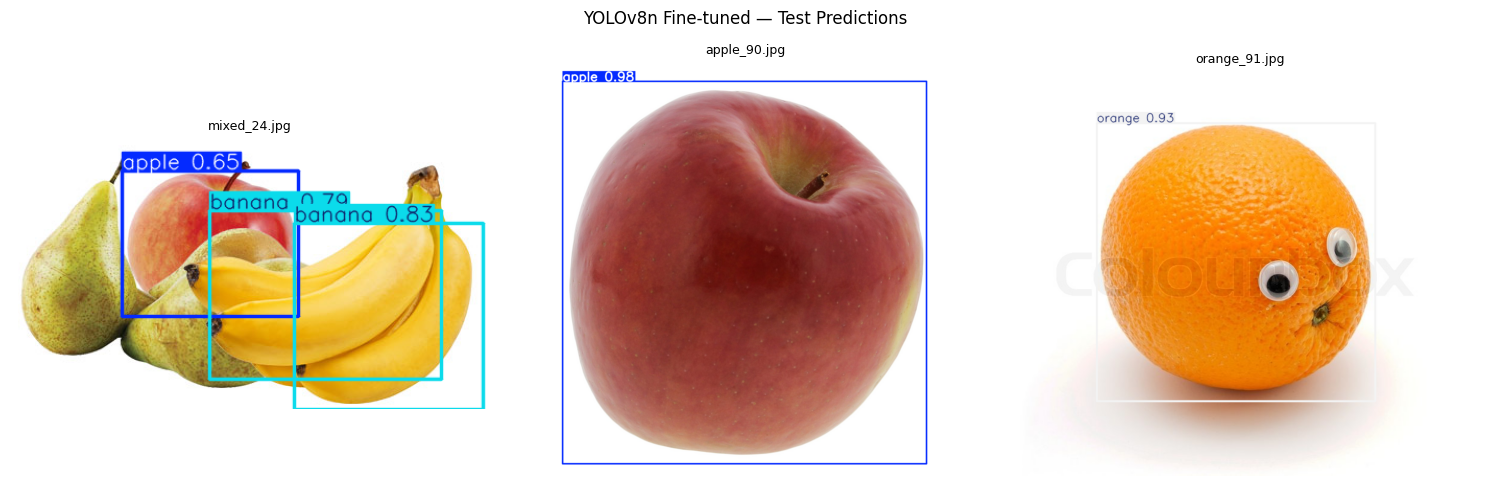

In [35]:
val_imgs    = sorted(glob.glob(os.path.join(YOLO_ROOT, 'val', 'images', '*.jpg')))
sample_3    = random.sample(val_imgs, min(3, len(val_imgs)))

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, path in zip(axes, sample_3):
    res = best_model.predict(path, conf=0.25, verbose=False)[0]
    ax.imshow(res.plot()[:,:,::-1])  # BGR to RGB
    ax.set_title(os.path.basename(path), fontsize=9)
    ax.axis('off')

plt.suptitle('YOLOv8n Fine-tuned — Test Predictions')
plt.tight_layout()
plt.show()

In [36]:
if not sample_3:
    raise RuntimeError('sample_3 is empty – run Cell 25 first.')

bench_path = sample_3[0]
bench_bgr  = cv2.imread(bench_path)
bench_rgb  = cv2.cvtColor(bench_bgr, cv2.COLOR_BGR2RGB)
bench_pil  = Image.fromarray(bench_rgb)
bench_t    = T.ToTensor()(bench_pil).to(device)
N = 10

# Faster R-CNN
_ = faster_rcnn([bench_t])  # warmup
t0 = time.time()
for _ in range(N):
    with torch.no_grad(): faster_rcnn([bench_t])
frcnn_ms = (time.time()-t0)/N*1000

# YOLO pretrained (reuse if already loaded)
if 'yolo_pt' not in dir():
    yolo_pt = YOLO('yolov8n.pt')
_ = yolo_pt.predict(bench_path, verbose=False)  # warmup
t0 = time.time()
for _ in range(N): yolo_pt.predict(bench_path, verbose=False)
yolo_pt_ms = (time.time()-t0)/N*1000

# YOLO fine-tuned
_ = best_model.predict(bench_path, verbose=False)  # warmup
t0 = time.time()
for _ in range(N): best_model.predict(bench_path, verbose=False)
yolo_ft_ms = (time.time()-t0)/N*1000

print(f'Faster R-CNN     : {frcnn_ms:.1f} ms')
print(f'YOLO pretrained  : {yolo_pt_ms:.1f} ms')
print(f'YOLO fine-tuned  : {yolo_ft_ms:.1f} ms')


Faster R-CNN     : 2158.7 ms
YOLO pretrained  : 58.0 ms
YOLO fine-tuned  : 54.3 ms


Ultralytics 8.4.33  Python-3.11.9 torch-2.2.2+cpu CPU (13th Gen Intel Core i5-13420H)
val: Fast image access  (ping: 0.00.0 ms, read: 1367.5871.5 MB/s, size: 184.3 KB)
val: Scanning C:\Users\VASU MONPARA\OneDrive\Desktop\Deep-Learning-SEM-2\Lab-4\yolo_dataset\val\labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2s/it 4.8s1.9ss
                   all         60        117      0.266      0.129      0.153     0.0998
Speed: 1.1ms preprocess, 68.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to C:\Users\VASU MONPARA\OneDrive\Desktop\Deep-Learning-SEM-2\Lab-4\runs\detect\val3
                    Model Inference Time (ms)  Precision     Recall     mAP@50  mAP@50-95
Faster R-CNN (pretrained)              2158.7 N/A (COCO) N/A (COCO) N/A (COCO) N/A (COCO)
        YOLO (pretrained)                58.0      0.266      0.129     

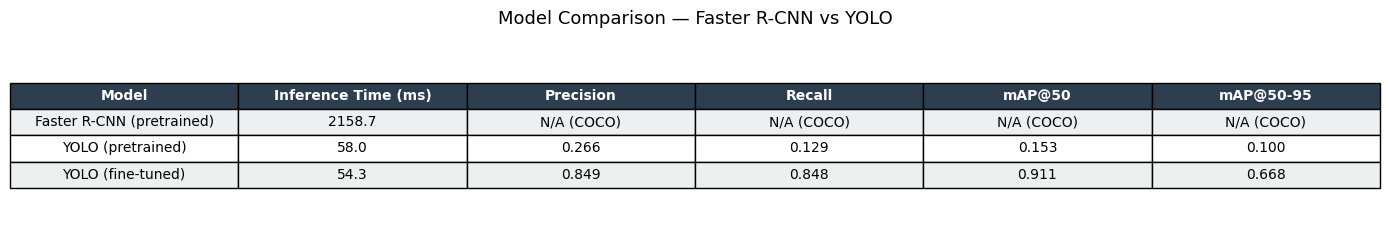

In [37]:
pt_metrics = yolo_pt.val(data=yaml_path, split='val', verbose=False)

df = pd.DataFrame({
    'Model'                 : ['Faster R-CNN (pretrained)','YOLO (pretrained)','YOLO (fine-tuned)'],
    'Inference Time (ms)'   : [f'{frcnn_ms:.1f}', f'{yolo_pt_ms:.1f}', f'{yolo_ft_ms:.1f}'],
    'Precision'             : ['N/A (COCO)', f'{pt_metrics.box.mp:.3f}', f'{prec:.3f}'],
    'Recall'                : ['N/A (COCO)', f'{pt_metrics.box.mr:.3f}', f'{rec:.3f}'],
    'mAP@50'                : ['N/A (COCO)', f'{pt_metrics.box.map50:.3f}', f'{map50:.3f}'],
    'mAP@50-95'             : ['N/A (COCO)', f'{pt_metrics.box.map:.3f}',  f'{map5095:.3f}'],
})

print(df.to_string(index=False))

# Render as matplotlib table
fig, ax = plt.subplots(figsize=(14, 2.5))
ax.axis('off')
tbl = ax.table(cellText=df.values, colLabels=df.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
for (row,col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 1:
        cell.set_facecolor('#ecf0f1')
plt.title('Model Comparison — Faster R-CNN vs YOLO', fontsize=13, pad=12)
plt.tight_layout()
plt.show()